In [11]:
import pandas as pd

In [12]:
results = pd.read_csv(r'../outputs/performance_metrics/results.csv')

In [13]:
results

,model,dataset,encoder,rows,pca_components,NMI,ARI,ACC,Purity
0,KMeans,agnews,tfidf,127600,249,0.0255,0.0019,0.2778,0.2780
1,KMeans,20newsgroups,sbert,18331,248,0.5308,0.3675,0.5655,0.5692
2,KMeans,bbcnews,tfidf,2225,244,0.9045,0.9301,0.9708,0.9708
3,KMeans,reuters,tfidf,7674,230,0.5340,0.3583,0.4881,0.8247
4,KMeans,dbpedia,tfidf,150000,229,0.5186,0.1337,0.3396,0.4266
5,KMeans,20newsgroups,tfidf,18331,252,0.4015,0.1333,0.3699,0.3975
6,KMeans,bbcnews,sbert,2225,160,0.8776,0.9060,0.9609,0.9609
7,KMeans,reuters,sbert,7674,179,0.6390,0.4739,0.6142,0.9029
8,KMeans,dbpedia,sbert,150000,209,0.7900,0.6895,0.7888,0.8162
9,KMeans,agnews,sbert,127600,235,0.5774,0.5932,0.8085,0.8085


In [14]:
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   model           30 non-null     object 
 1   dataset         30 non-null     object 
 2   encoder         30 non-null     object 
 3   rows            30 non-null     int64  
 4   pca_components  30 non-null     int64  
 5   NMI             30 non-null     float64
 6   ARI             30 non-null     float64
 7   ACC             30 non-null     float64
 8   Purity          30 non-null     float64
dtypes: float64(4), int64(2), object(3)
memory usage: 2.2+ KB


In [15]:
encoder_trends = (
    results.groupby("encoder")[["ACC", "NMI", "ARI", "Purity"]]
    .mean()
    .round(4)
    .sort_values(by="ACC", ascending=False)
)
encoder_trends.to_excel('../outputs/encoder_wise_trends.xlsx')

In [16]:
model_trends = (
    results.groupby("model")[["ACC", "NMI", "ARI", "Purity"]]
    .mean()
    .round(4)
    .sort_values(by="ACC", ascending=False)
)

model_trends.to_excel('../outputs/model_wise_trends.xlsx')

In [17]:
model_encoder_trends = (
    results.groupby(["model", "encoder"])[["ACC", "NMI", "ARI", "Purity"]]
    .mean()
    .round(4)
)

model_encoder_trends.to_excel('../outputs/model_and_encoder_wise_trends.xlsx')

In [18]:
dataset_trends = (
    results.groupby("dataset")[["ACC", "NMI", "ARI", "Purity"]]
    .mean()
    .round(4)
    .sort_values(by="ACC", ascending=False)
)
dataset_trends.to_excel('../outputs/dataset_wise_trends.xlsx')

In [19]:
encoder_gain = (
    results.groupby("encoder")[["ACC", "NMI", "ARI"]]
    .mean()
    .round(4)
)

gain = encoder_gain.loc["sbert"] - encoder_gain.loc["tfidf"]

gain

ACC    0.1774
NMI    0.1870
ARI    0.2127
dtype: float64

In [20]:
deep_models = ["IDEC", "SDCN"]

deep_avg = (
    results[results["model"].isin(deep_models)]
    [["ACC", "NMI", "ARI", "Purity"]]
    .mean()
)

kmeans_avg = (
    results[results["model"] == "KMeans"]
    [["ACC", "NMI", "ARI", "Purity"]]
    .mean()
)

comparison = pd.DataFrame({
    "KMeans": kmeans_avg,
    "Deep Models": deep_avg
}).round(4)

comparison

,KMeans,Deep Models
ACC,0.6184,0.5722
NMI,0.5799,0.4900
ARI,0.4587,0.4180
Purity,0.6955,0.6482


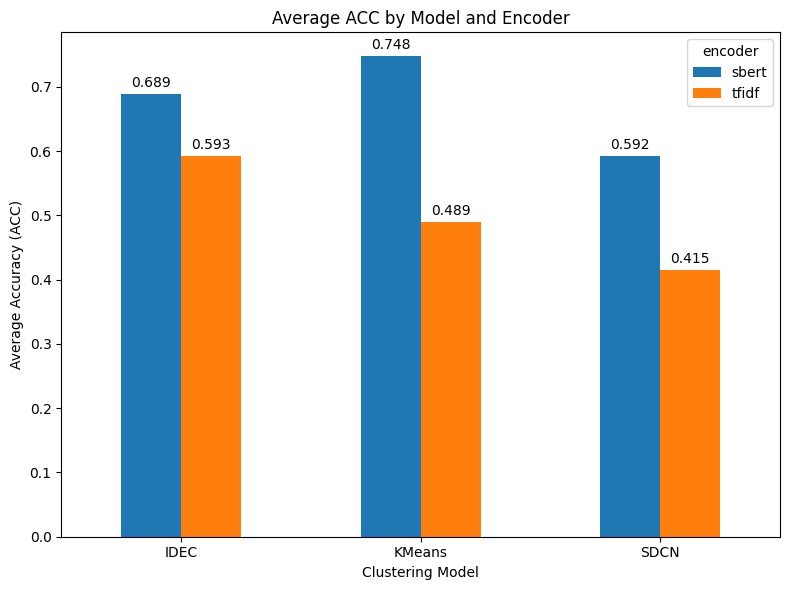

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plot_df = (
    results
    .groupby(["model", "encoder"])["ACC"]
    .mean()
    .reset_index()
)


pivot_df = plot_df.pivot(
    index="model",
    columns="encoder",
    values="ACC"
)


ax = pivot_df.plot(
    kind="bar",
    figsize=(8, 6)
)

plt.title("Average ACC by Model and Encoder")
plt.xlabel("Clustering Model")
plt.ylabel("Average Accuracy (ACC)")
plt.xticks(rotation=0)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

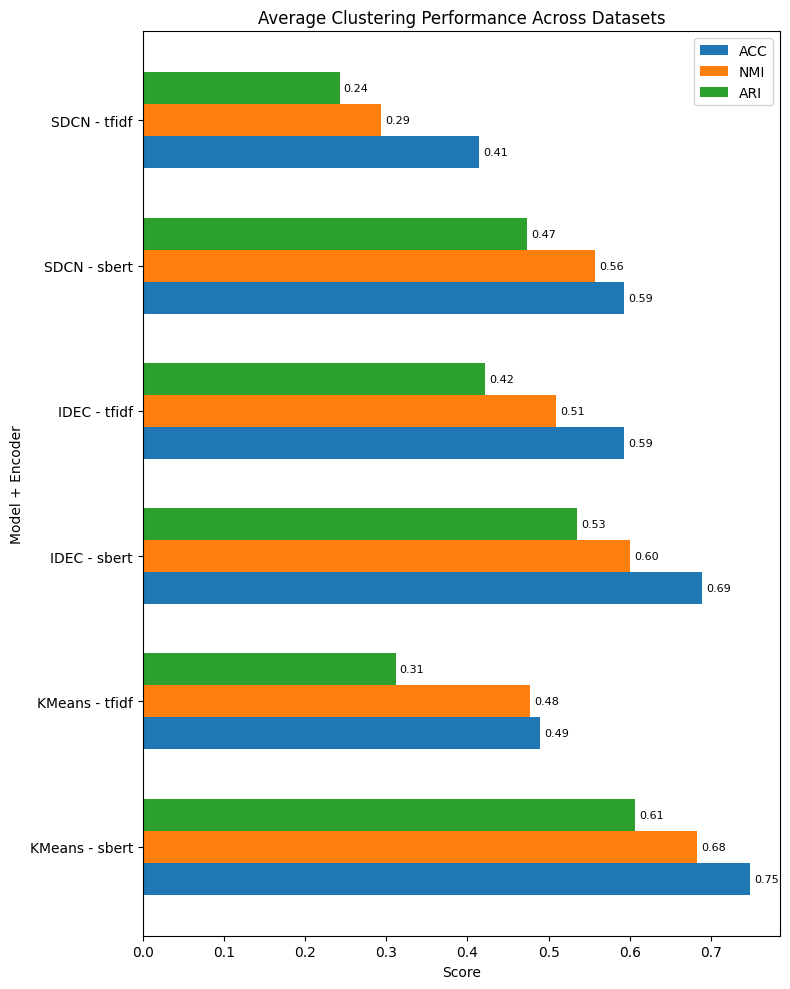

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------
# Aggregate averages
# -----------------------------------

plot_df = (
    results
    .groupby(["model", "encoder"])[["ACC", "NMI", "ARI"]]
    .mean()
    .reset_index()
)

# Optional ordering
model_order = ["KMeans", "IDEC", "SDCN"]

plot_df["model"] = pd.Categorical(
    plot_df["model"],
    categories=model_order,
    ordered=True
)

plot_df = plot_df.sort_values(["model", "encoder"])

# -----------------------------------
# Labels
# -----------------------------------

plot_df["label"] = (
    plot_df["model"].astype(str) + " - " + plot_df["encoder"]
)

# -----------------------------------
# Positions
# -----------------------------------

y = np.arange(len(plot_df))

height = 0.22

# -----------------------------------
# Plot
# -----------------------------------

fig, ax = plt.subplots(figsize=(8, 10))

bars1 = ax.barh(
    y - height,
    plot_df["ACC"],
    height,
    label="ACC"
)

bars2 = ax.barh(
    y,
    plot_df["NMI"],
    height,
    label="NMI"
)

bars3 = ax.barh(
    y + height,
    plot_df["ARI"],
    height,
    label="ARI"
)

# -----------------------------------
# Labels & Formatting
# -----------------------------------

ax.set_title("Average Clustering Performance Across Datasets")

ax.set_xlabel("Score")
ax.set_ylabel("Model + Encoder")

ax.set_yticks(y)
ax.set_yticklabels(plot_df["label"])

ax.legend()

# -----------------------------------
# Value labels
# -----------------------------------

for bars in [bars1, bars2, bars3]:

    ax.bar_label(
        bars,
        fmt="%.2f",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [30]:
# -----------------------------------
# Best Performing Configurations Table
# -----------------------------------

metrics = ["ACC", "NMI", "ARI", "Purity"]

best_rows = []

for metric in metrics:

    best_idx = results[metric].idxmax()

    row = results.loc[best_idx]

    best_rows.append({
        "Metric": metric,
        "Model": row["model"],
        "Dataset": row["dataset"],
        "Encoder": row["encoder"],
        "Score": round(row[metric], 4)
    })

best_df = pd.DataFrame(best_rows)

# -----------------------------------
# Display
# -----------------------------------

print(best_df)

# Optional prettier display in notebook
display(best_df)

   Metric   Model  Dataset Encoder   Score
0     ACC  KMeans  bbcnews   tfidf  0.9708
1     NMI  KMeans  bbcnews   tfidf  0.9045
2     ARI  KMeans  bbcnews   tfidf  0.9301
3  Purity  KMeans  bbcnews   tfidf  0.9708


,Metric,Model,Dataset,Encoder,Score
0,ACC,KMeans,bbcnews,tfidf,0.9708
1,NMI,KMeans,bbcnews,tfidf,0.9045
2,ARI,KMeans,bbcnews,tfidf,0.9301
3,Purity,KMeans,bbcnews,tfidf,0.9708
